In [1]:
# ===== 请将您的实验日志全文粘贴到下面的三引号字符串中 =====
data = """
------------------------------ Experiment: KAN, Standard, (Adam+LBFGS),  ------------------------------
[0.022331552696370143, 0.022706053049940333, 0.04263635483894554, 0.026563952510811634, 0.017689161533165645, 0.012948087759152405, 0.0465189064474392, 0.015245928451555505, 0.03040330554446506, 0.017010996920170947]
Error u of fuhe active learning(LHS sampling): 2.540543e-02
[0.0048416180679822, 0.004888930319557157, 0.009871727110810528, 0.006260543634118076, 0.0043245214790340126, 0.003352529630615454, 0.01091773683173025, 0.003633966677041109, 0.006849111385569699, 0.0039030077978962252]
MAE of fuhe active learning(LHS sampling): 5.884369e-03
[0.00022709978136664364, 0.00023478058040692448, 0.0008278259027968393, 0.0003213396126616865, 0.0001424929478704148, 7.634667788363897e-05, 0.0009854574324328067, 0.00010584896849630108, 0.00042094027809500597, 0.00013177663319596396]
MSE of fuhe active learning(LHS sampling): 3.473909e-04


------------------------------ Experiment: KAN, Residual, (Adam+LBFGS),  ------------------------------
[0.03396333896109512, 0.01958591032115781, 0.016791865368311183, 0.0279896677430497, 0.018957804799685018, 0.03568692395181651, 0.01649687245065086, 0.02849661731212977, 0.018347646507069076, 0.012978373773111554]
Error u of fuhe active learning(LHS sampling): 2.292950e-02
[0.007938951781510696, 0.00439900579798311, 0.004262751480360243, 0.006946561564315327, 0.004938541529722236, 0.009235671662614194, 0.004248088489996898, 0.006766122063728612, 0.0037515885882656603, 0.0030552541777592117]
MAE of fuhe active learning(LHS sampling): 5.554254e-03
[0.0005252906063589921, 0.00017468933791680476, 0.00012840347067699686, 0.0003567585267013301, 0.00016366468160452109, 0.0005799587515487836, 0.00012393161484853564, 0.0003697987986080278, 0.00015329909959693505, 7.670425049124221e-05]
MSE of fuhe active learning(LHS sampling): 2.652499e-04


------------------------------ Experiment: KAN, Failure, (Adam+LBFGS),  ------------------------------
[0.01666725813558625, 0.0843400348325958, 0.036705720889906014, 0.05165199524112, 0.0648046623450735, 0.08161588555628216, 0.03575297777735924, 0.12596717196558435, 0.15349301399090673, 0.07641528648191151]
Error u of fuhe active learning(LHS sampling): 7.274140e-02
[0.005124281774865001, 0.029994226587627897, 0.009853392892800761, 0.014281924901624523, 0.015782003811050046, 0.02047120534009396, 0.01024418009974409, 0.035552687914465, 0.03592916522746474, 0.01861565141686905]
MAE of fuhe active learning(LHS sampling): 1.958487e-02
[0.00012650485664253547, 0.003239264620266642, 0.0006135449577746694, 0.0012149351028214817, 0.00191245568159489, 0.003033390134274929, 0.0005821076589371867, 0.007225928070743871, 0.010728922384090707, 0.0026591287574481023]
MSE of fuhe active learning(LHS sampling): 3.133618e-03

------------------------------ Experiment: KAN, Failure + Residual, (Adam+LBFGS),  ------------------------------
[0.0663287525327129, 0.02630030858523017, 0.044182562847002824, 0.025324622674941077, 0.05001711145057797, 0.014130866845126594, 0.009057073235176172, 0.03701422835819602, 0.028962287250531918, 0.02813033275568759]
Error u of fuhe active learning(LHS sampling): 3.294481e-02
[0.01419445663381645, 0.006751385883962806, 0.00966806750534777, 0.005871600380582554, 0.01122718836532256, 0.003533223650983939, 0.0024463139827440444, 0.009984909217228844, 0.007429831875315229, 0.006350137968000914]
MAE of fuhe active learning(LHS sampling): 7.745712e-03
[0.002003468573358575, 0.0003149927542303899, 0.0008889568550859927, 0.0002920551320263203, 0.0011392422679047118, 9.093194564303992e-05, 3.735550693632891e-05, 0.0006239018530509081, 0.000381983486807322, 0.0003603533920786399]
MSE of fuhe active learning(LHS sampling): 6.133242e-04



"""

In [2]:
import re
import numpy as np


# ===== 解析代码 =====
def parse_error_u(text):
    """
    从日志文本中提取每个实验名称及其对应的 error u 列表（10个数字）
    """
    # 按实验块分割
    blocks = re.split(r'\-{30,} Experiment: ', text)
    experiments = {}
    for block in blocks:
        if not block.strip():
            continue
        lines = block.strip().split('\n')
        if not lines:
            continue
        # 第一行是实验名称（可能包含前导空格，但已经被strip去掉）
        exp_name = lines[0].strip()
        # 在后续行中找以 '[' 开头的行，取第一个这样的行作为 error u 列表
        for line in lines[1:]:
            line = line.strip()
            if line.startswith('['):
                # 提取所有浮点数
                nums = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if nums:
                    values = [float(x) for x in nums]
                    if len(values) == 10:   # 假设就是10个seed
                        experiments[exp_name] = values
                        break
    return experiments

def compute_stats(exp_dict):
    results = []
    for name, vals in exp_dict.items():
        mean = np.mean(vals)
        var = np.var(vals, ddof=1)   # 样本方差
        std = np.std(vals, ddof=1)
        results.append((name, vals, mean, var, std))
    results.sort(key=lambda x: x[2])  # 按均值升序
    return results

def print_results(results):
    print("\n========== 各实验 Error u 统计比较（按均值升序） ==========\n")
    print(f"{'实验名称':<45} {'均值':<12} {'样本方差':<14} {'标准差':<12} {'10个seed的error u'}")
    print("-" * 130)
    for name, vals, mean, var, std in results:
        vals_str = ", ".join([f"{v:.4f}" for v in vals])
        print(f"{name:<45} {mean:.6f}    {var:.6f}     {std:.6f}    [{vals_str}]")
    print("\n")

# 运行
if __name__ == "__main__":
    exp_dict = parse_error_u(data)
    if not exp_dict:
        print("未解析到任何实验数据，请检查文本格式。")
    else:
        results = compute_stats(exp_dict)
        print_results(results)


========== 各实验 Error u 统计比较（按均值升序） ==========

实验名称                                          均值           样本方差           标准差          10个seed的error u
----------------------------------------------------------------------------------------------------------------------------------
KAN, Residual, (Adam+LBFGS),  ------------------------------ 0.022930    0.000063     0.007938    [0.0340, 0.0196, 0.0168, 0.0280, 0.0190, 0.0357, 0.0165, 0.0285, 0.0183, 0.0130]
KAN, Standard, (Adam+LBFGS),  ------------------------------ 0.025405    0.000130     0.011422    [0.0223, 0.0227, 0.0426, 0.0266, 0.0177, 0.0129, 0.0465, 0.0152, 0.0304, 0.0170]
KAN, Failure + Residual, (Adam+LBFGS),  ------------------------------ 0.032945    0.000291     0.017045    [0.0663, 0.0263, 0.0442, 0.0253, 0.0500, 0.0141, 0.0091, 0.0370, 0.0290, 0.0281]
KAN, Failure, (Adam+LBFGS),  ------------------------------ 0.072741    0.001767     0.042031    [0.0167, 0.0843, 0.0367, 0.0517, 0.0648, 0.0816, 0.0358, 0.1260, 0.1535, 0

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_min_values(exp_dict, top_n=None, save_path=None):
    """
    绘制每个实验的10个seed中的最小值的柱状图（按最小值升序排列）
    
    参数:
        exp_dict: 解析后的实验字典
        top_n: 只显示最小值最小的前N个实验（None表示全部）
        save_path: 保存图片路径，如 'min_values.png'，为None则显示
    """
    # 计算每个实验的最小值
    min_vals = {name: np.min(vals) for name, vals in exp_dict.items()}
    # 按最小值升序排序
    sorted_items = sorted(min_vals.items(), key=lambda x: x[1])
    if top_n is not None:
        sorted_items = sorted_items[:top_n]
    
    names = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(names, values, color='skyblue', edgecolor='black')
    
    # 在柱顶标注数值
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel('Minimum Error u (among 10 seeds)', fontsize=12)
    ax.set_title('Comparison of Minimum Error u across Experiments', fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()

def plot_seed_trends(exp_dict, highlight_best=True, save_path=None):
    """
    绘制每个实验的10个seed值的折线图（x轴为seed编号1~10）
    
    参数:
        exp_dict: 解析后的实验字典
        highlight_best: 是否用特殊颜色突出显示均值最小的实验
        save_path: 保存图片路径
    """
    # 按均值排序，以便图例有序
    sorted_names = sorted(exp_dict.keys(), key=lambda name: np.mean(exp_dict[name]))
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 定义颜色循环（可自定义）
    colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_names)))
    
    # 找出均值最小的实验（最优）
    best_name = sorted_names[0] if highlight_best else None
    
    for i, name in enumerate(sorted_names):
        vals = exp_dict[name]
        seeds = range(1, 11)
        # 如果是最优实验，用红色粗线突出显示
        if highlight_best and name == best_name:
            line, = ax.plot(seeds, vals, marker='o', linestyle='-', linewidth=3,
                            color='red', label=f"{name} (best mean)", markersize=6)
        else:
            line, = ax.plot(seeds, vals, marker='o', linestyle='-', linewidth=1.5,
                            color=colors[i], label=name, markersize=5, alpha=0.8)
    
    ax.set_xlabel('Seed Index', fontsize=12)
    ax.set_ylabel('Error u', fontsize=12)
    ax.set_title('Error u across 10 Seeds for Each Experiment', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    plt.xticks(range(1, 11))
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()

def plot_seed_comparison(exp_dict, seed_index=1, top_n=None, save_path=None):
    """
    绘制在指定 seed 下，各实验的 Error u 对比柱状图（按该 seed 值升序排列）
    
    参数:
        exp_dict: 解析后的实验字典 {实验名: [10个误差值]}
        seed_index: 指定的 seed 编号（从1开始），默认为1（即第一个seed）
        top_n: 只显示该 seed 值最小的前 N 个实验，None 表示全部显示
        save_path: 保存图片路径，如 'seed5_comparison.png'，为None则显示
    """
    # 检查 seed_index 是否有效
    if seed_index < 1 or seed_index > 10:
        raise ValueError("seed_index 必须在 1 到 10 之间")
    
    idx = seed_index - 1  # 转为0-based索引
    
    # 提取每个实验在该 seed 下的值
    seed_values = {}
    for name, vals in exp_dict.items():
        if len(vals) < idx + 1:
            print(f"警告：实验 '{name}' 的列表长度不足 {seed_index}，跳过")
            continue
        seed_values[name] = vals[idx]
    
    if not seed_values:
        print("没有可用的实验数据，请检查")
        return
    
    # 按该 seed 值升序排序
    sorted_items = sorted(seed_values.items(), key=lambda x: x[1])
    if top_n is not None:
        sorted_items = sorted_items[:top_n]
    
    names = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(names, values, color='lightcoral', edgecolor='black')
    
    # 在柱顶标注数值
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel(f'Error u at Seed {seed_index}', fontsize=12)
    ax.set_title(f'Comparison of Error u at Seed {seed_index} across Experiments', fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_mean_variance_combined(exp_dict, top_n=None, save_path=None):
    """
    在双Y轴图中同时展示各实验的均值和样本方差（按均值升序排列）

    参数:
        exp_dict: 解析后的实验字典 {实验名: [10个误差值]}
        top_n: 只显示均值最小的前N个实验，None表示全部
        save_path: 保存图片路径，为None则直接显示
    """
    # 计算均值和样本方差
    means = {}
    variances = {}
    for name, vals in exp_dict.items():
        means[name] = np.mean(vals)
        variances[name] = np.var(vals, ddof=1) if len(vals) > 1 else 0.0

    # 按均值升序排序
    sorted_names = sorted(means.keys(), key=lambda x: means[x])
    if top_n is not None:
        sorted_names = sorted_names[:top_n]

    names = sorted_names
    mean_vals = [means[n] for n in names]
    var_vals = [variances[n] for n in names]

    # 创建图形和双轴
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax2 = ax1.twinx()

    # 左轴：均值柱状图
    x_pos = np.arange(len(names))
    bars = ax1.bar(x_pos, mean_vals, color='skyblue', edgecolor='black',
                   alpha=0.8, label='Mean Error u')
    ax1.set_ylabel('Mean Error u', fontsize=12, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # 在柱顶标注均值数值
    for bar, val in zip(bars, mean_vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8, color='blue')

    # 右轴：方差折线图（用红色圆点标记）
    line, = ax2.plot(x_pos, var_vals, marker='o', linestyle='-', color='red',
                     linewidth=2, markersize=8, label='Variance')
    ax2.set_ylabel('Sample Variance', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # 在折线上标注方差数值
    for i, val in enumerate(var_vals):
        ax2.text(i, val + 0.001, f'{val:.6f}', ha='center', va='bottom',
                 fontsize=7, color='red')

    # 合并图例
    lines = [bars, line]
    labels = ['Mean Error u', 'Variance']
    ax1.legend(lines, labels, loc='upper left', fontsize=10)

    ax1.set_title('Mean and Variance of Error u across 10 Seeds', fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()



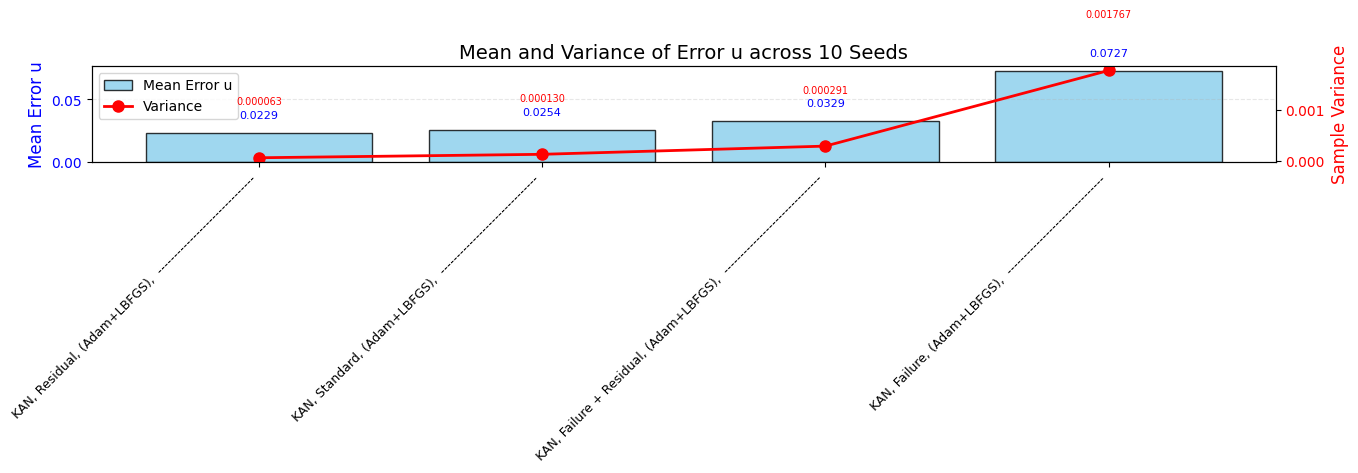

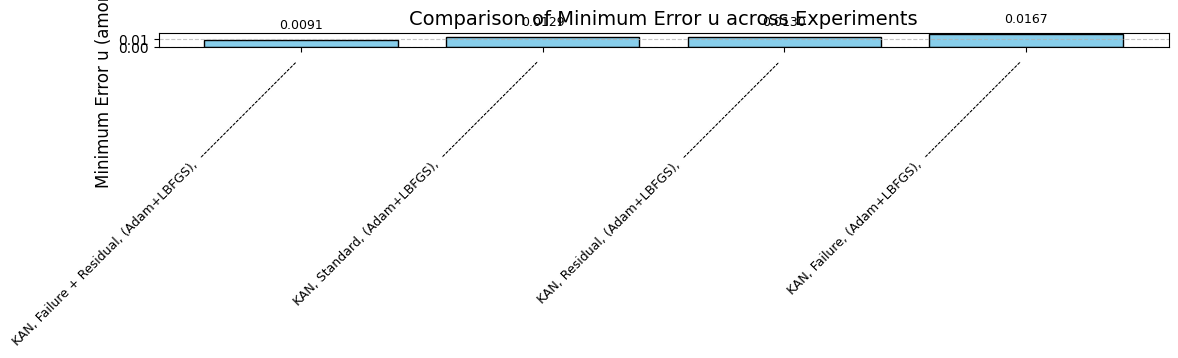

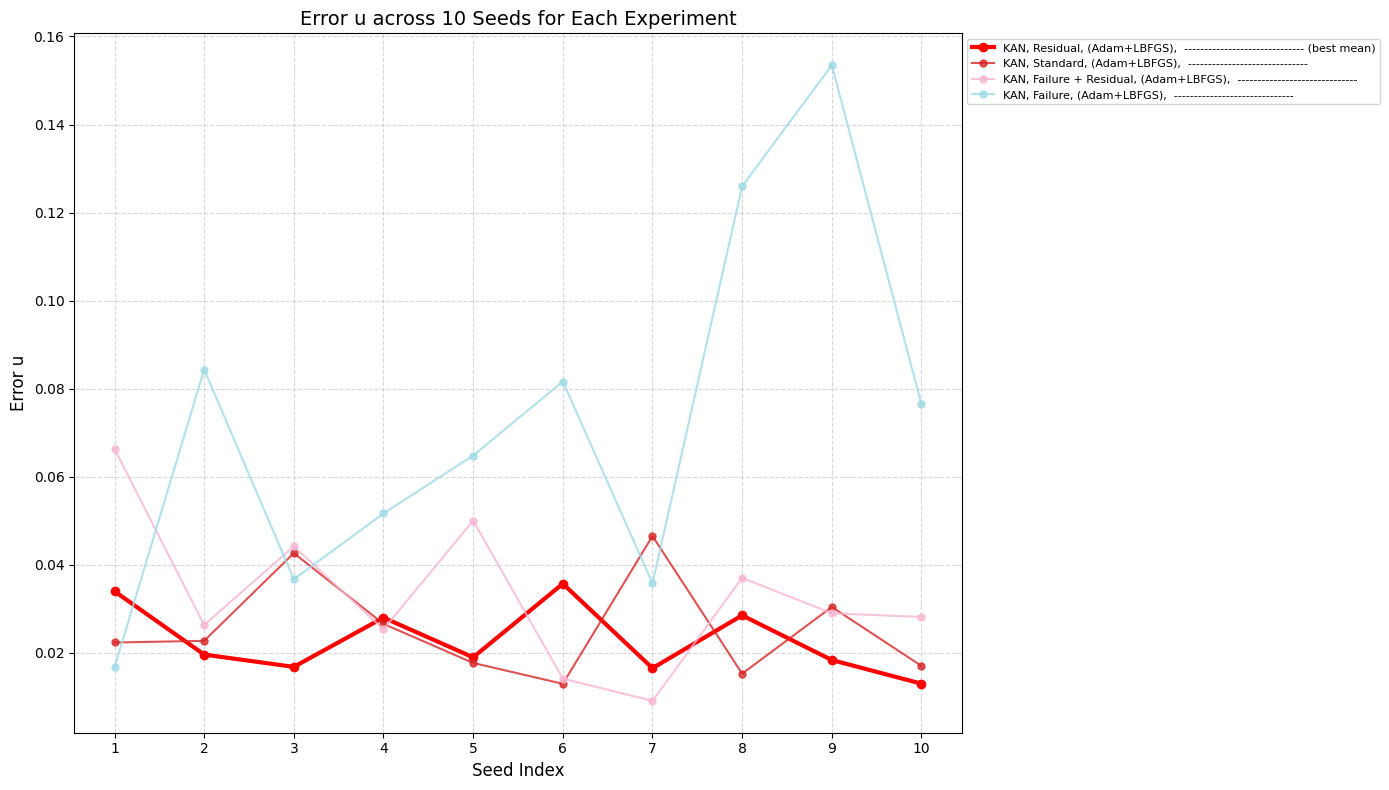

In [4]:

plot_mean_variance_combined(exp_dict)

# 绘制最小值柱状图（显示全部实验）
plot_min_values(exp_dict)

# 绘制折线图
plot_seed_trends(exp_dict)


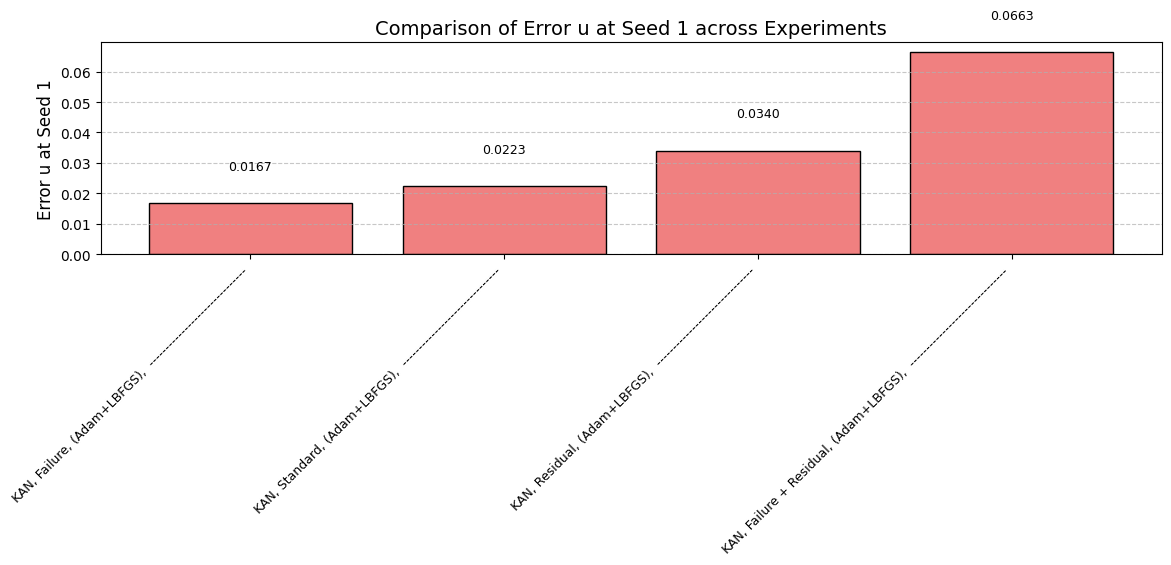

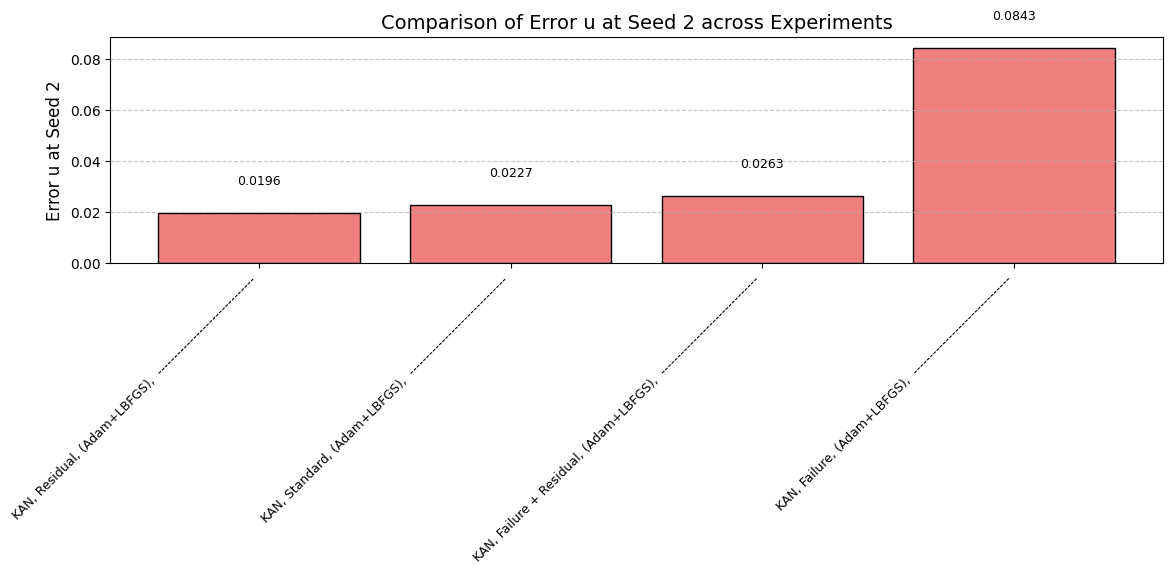

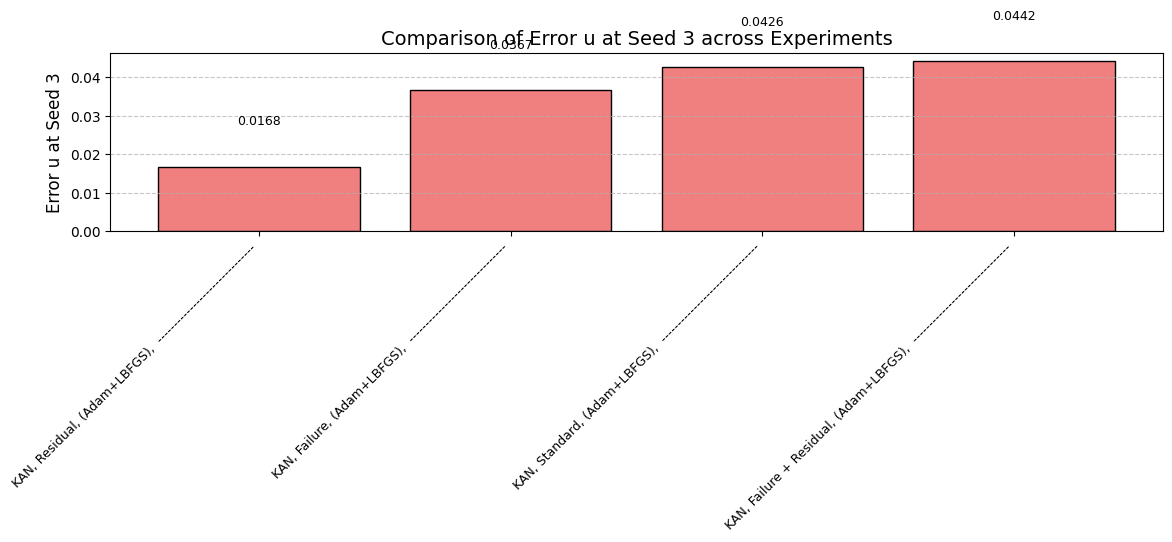

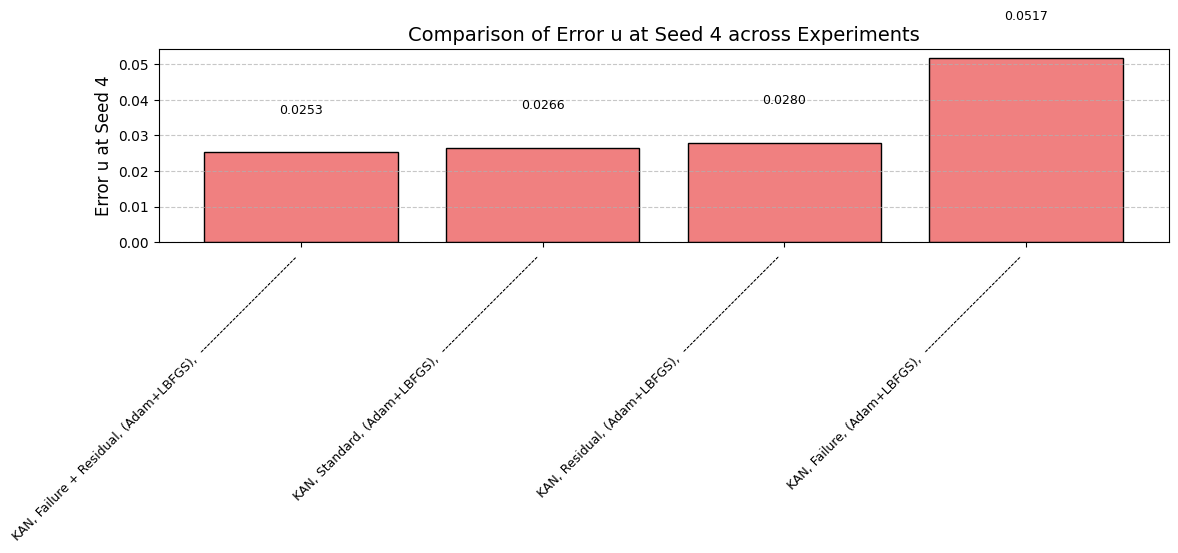

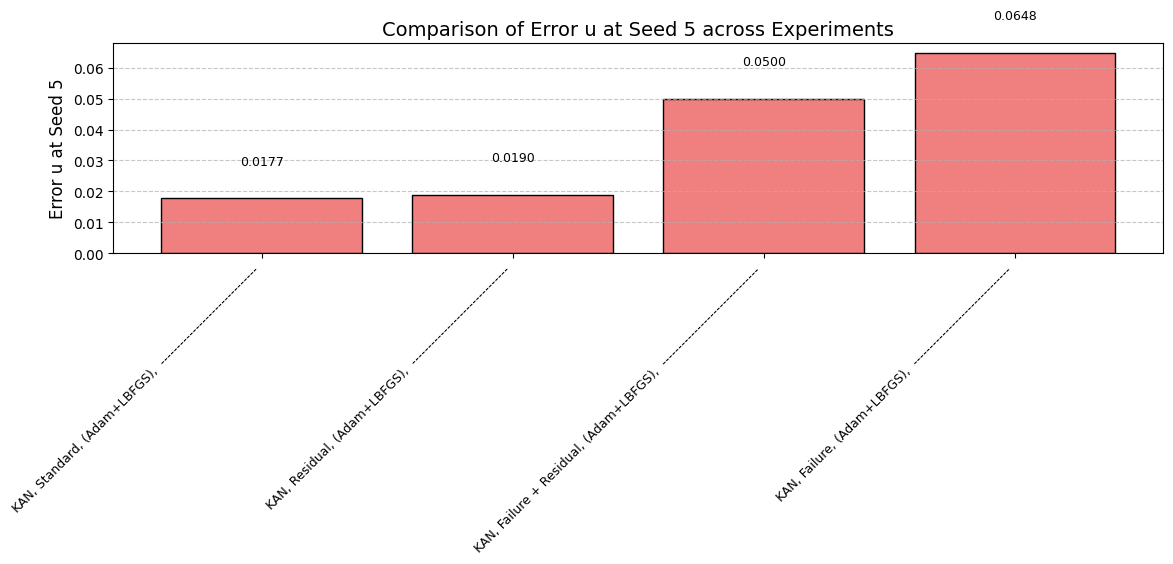

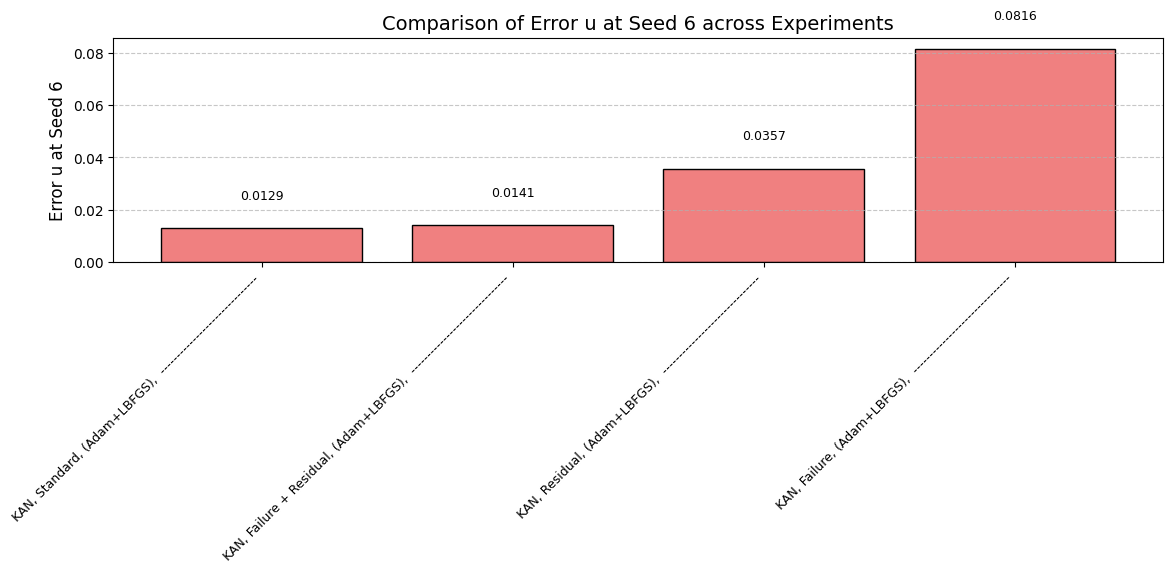

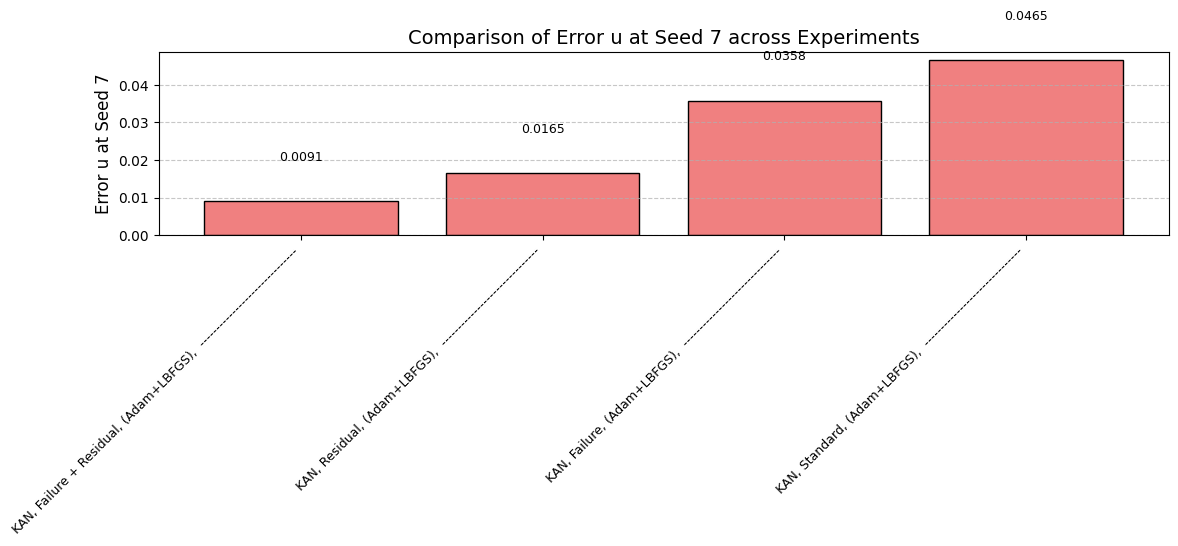

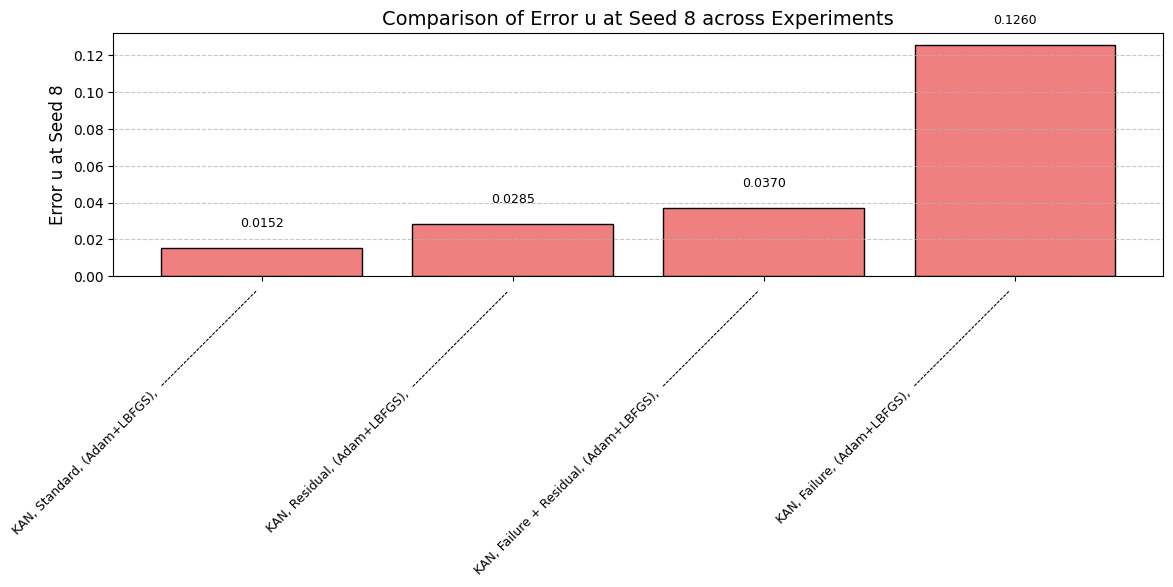

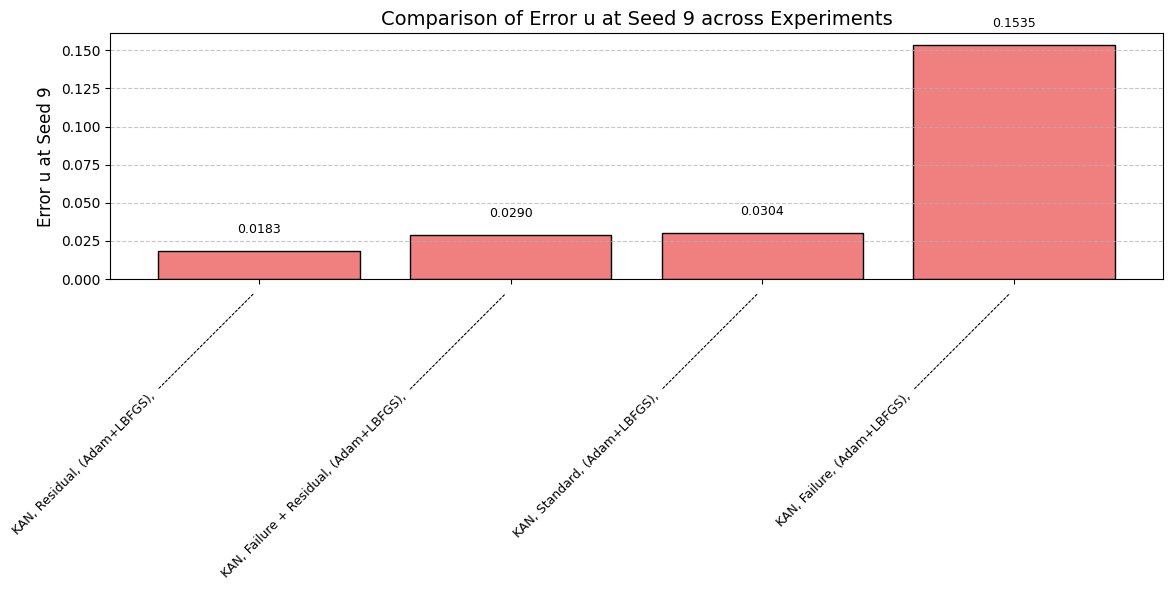

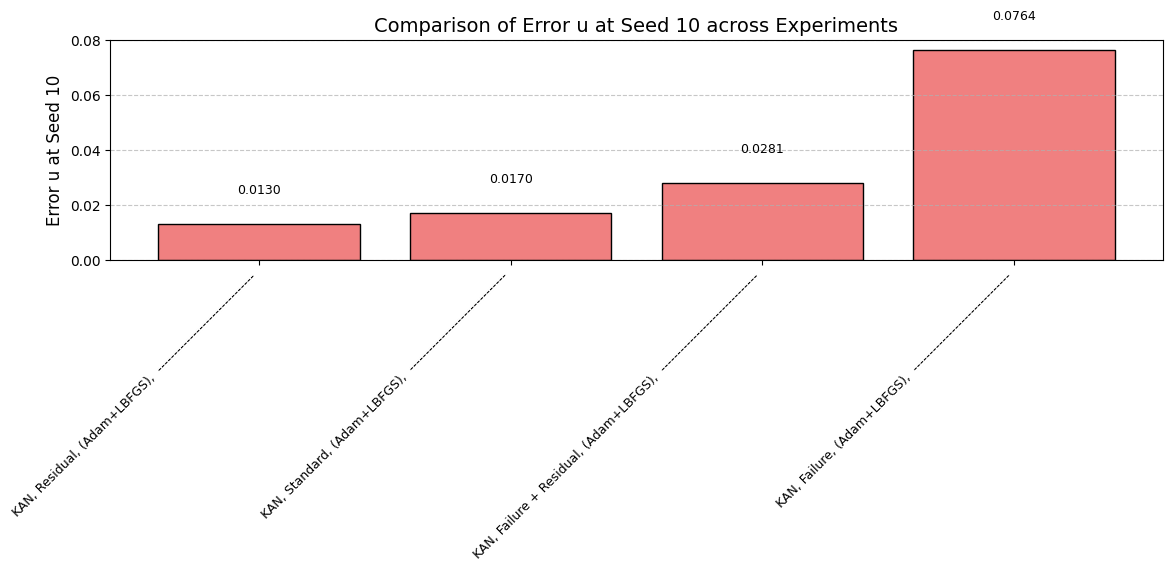

In [5]:
for i in range(10):
    plot_seed_comparison(exp_dict, seed_index = i+1)
# plot_seed_comparison(exp_dict, seed_index=10)